In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.metrics import silhouette_score
from geopy.distance import geodesic
from geopy.geocoders import Nominatim
from geopy.exc import GeocoderTimedOut, GeocoderServiceError
import time

#DATA COLLECTING

Load Dataset & Setup

In [ ]:
# ========== SETUP ==========
geolocator = Nominatim(user_agent="kasyik_tourism_app")

# ========== LOAD DATASET ==========
df = pd.read_csv('tourism_with_id.csv')
print(f"Dataset dimuat: {len(df)} tempat wisata\n")

Dataset dimuat: 437 tempat wisata



#Preprocessing

Hapus baris tanpa koordinat


In [ ]:
# ========== PREPROCESSING ==========
df_filled = df.copy()

# Hapus baris tanpa koordinat
df_filled = df_filled.dropna(subset=['Lat', 'Long'])

Isi price

In [ ]:
# Isi Price dengan median per kategori
df_filled['Price'] = df_filled.groupby('Category')['Price'].transform(
    lambda x: x.fillna(x.median())
)

Isi rating

In [ ]:
# Isi Rating dengan median
df_filled['Rating'] = df_filled['Rating'].fillna(df_filled['Rating'].median())

Hapus baris kosong

In [ ]:
# Hapus baris yang masih punya NaN
df_filled = df_filled.dropna(subset=['Price', 'Rating', 'Lat', 'Long'])
print(f"Setelah preprocessing: {len(df_filled)} tempat wisata\n")

Setelah preprocessing: 437 tempat wisata



In [ ]:
# Prepare data untuk clustering
X = df_filled[['Price', 'Rating', 'Lat', 'Long']].copy()
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
df = df_filled

#KLASTERISASI K-MEANS

##Menentukan cluster

Elbow Method

ELBOW METHOD
K=2 → WCSS = 1164.17
K=3 → WCSS = 925.16
K=4 → WCSS = 752.96
K=5 → WCSS = 638.08
K=6 → WCSS = 561.99
K=7 → WCSS = 461.28
K=8 → WCSS = 407.59
K=9 → WCSS = 352.24
K=10 → WCSS = 327.10


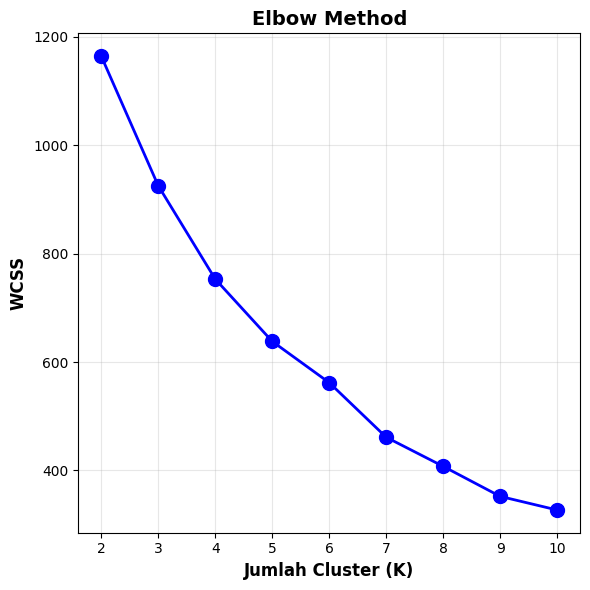

In [ ]:
# ========== ELBOW METHOD ==========
print("="*80)
print("ELBOW METHOD")
print("="*80)

wcss = []
K_range = range(2, 11)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)
    print(f"K={k} → WCSS = {kmeans.inertia_:.2f}")

# Plot Elbow
plt.figure(figsize=(6, 6))
plt.plot(K_range, wcss, 'bo-', linewidth=2, markersize=10)
plt.xlabel('Jumlah Cluster (K)', fontsize=12, fontweight='bold')
plt.ylabel('WCSS', fontsize=12, fontweight='bold')
plt.title('Elbow Method', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3)
plt.xticks(K_range)
plt.tight_layout()
plt.show()

Silhouette Score


SILHOUETTE SCORE
K=2 → Silhouette Score = 0.4043
K=3 → Silhouette Score = 0.4188
K=4 → Silhouette Score = 0.4081
K=5 → Silhouette Score = 0.4272
K=6 → Silhouette Score = 0.3020
K=7 → Silhouette Score = 0.3314
K=8 → Silhouette Score = 0.2947
K=9 → Silhouette Score = 0.3382
K=10 → Silhouette Score = 0.3384


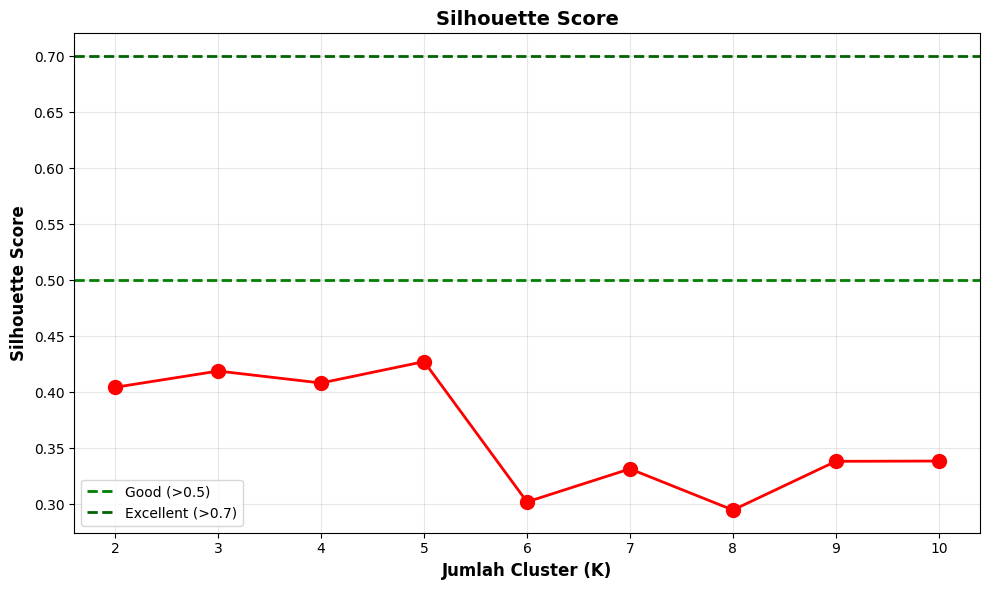


✓ K optimal: 5 (Silhouette Score: 0.4272)


In [ ]:
# ========== SILHOUETTE SCORE ==========
print("\n" + "="*80)
print("SILHOUETTE SCORE")
print("="*80)

silhouette_scores = []

for k in K_range:
    kmeans_temp = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans_temp.fit_predict(X_scaled)
    sil_score = silhouette_score(X_scaled, labels)
    silhouette_scores.append(sil_score)
    print(f"K={k} → Silhouette Score = {sil_score:.4f}")

# Plot Silhouette
plt.figure(figsize=(10, 6))
plt.plot(K_range, silhouette_scores, 'ro-', linewidth=2, markersize=10)
plt.xlabel('Jumlah Cluster (K)', fontsize=12, fontweight='bold')
plt.ylabel('Silhouette Score', fontsize=12, fontweight='bold')
plt.title('Silhouette Score', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3)
plt.xticks(K_range)
plt.axhline(y=0.5, color='g', linestyle='--', linewidth=2, label='Good (>0.5)')
plt.axhline(y=0.7, color='darkgreen', linestyle='--', linewidth=2, label='Excellent (>0.7)')
plt.legend()
plt.tight_layout()
plt.show()

best_k = K_range[silhouette_scores.index(max(silhouette_scores))]
print(f"\n✓ K optimal: {best_k} (Silhouette Score: {max(silhouette_scores):.4f})")

K-Means

In [ ]:
# ========== K-MEANS CLUSTERING ==========
print(f"\n{'='*80}")
print(f"CLUSTERING dengan K={best_k}")
print(f"{'='*80}")

kmeans = KMeans(n_clusters=best_k, random_state=42, n_init=10)
df['Cluster'] = kmeans.fit_predict(X_scaled)

print(f"\n✓ Clustering selesai!")
print(f"\nDistribusi cluster:")
print(df['Cluster'].value_counts().sort_index())

# ========== STATISTIK CLUSTER ==========
print(f"\n{'='*80}")
print("STATISTIK PER CLUSTER")
print(f"{'='*80}\n")

cluster_stats = df.groupby('Cluster')[['Price', 'Rating']].agg(['mean', 'min', 'max', 'count'])
print(cluster_stats)


CLUSTERING dengan K=5

✓ Clustering selesai!

Distribusi cluster:
Cluster
0     54
1     16
2      1
3    168
4    198
Name: count, dtype: int64

STATISTIK PER CLUSTER

                 Price                          Rating                
                  mean     min     max count      mean  min  max count
Cluster                                                               
0         17981.481481       0  150000    54  4.053704  3.4  4.2    54
1        284375.000000  150000  900000    16  4.468750  4.0  4.8    16
2        175000.000000  175000  175000     1  4.400000  4.4  4.4     1
3         15541.666667       0  150000   168  4.512500  4.2  5.0   168
4         12454.545455       0  150000   198  4.487879  4.2  5.0   198


#Visualisasi Klasterisasi

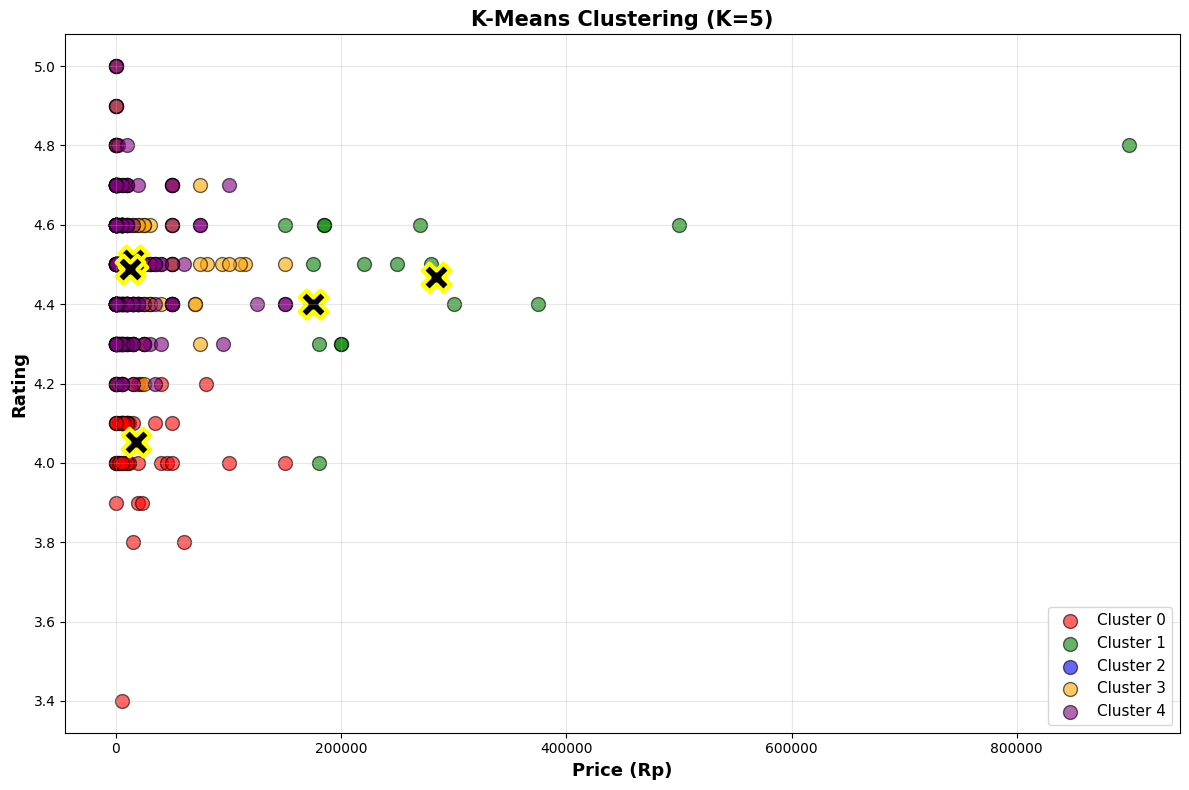

In [ ]:
# ========== VISUALISASI ==========
# VIZ 1: Scatter Plot
centroids = []
for cluster_id in range(best_k):
    cluster_data = df[df['Cluster'] == cluster_id]
    centroid = [cluster_data['Price'].mean(), cluster_data['Rating'].mean()]
    centroids.append(centroid)

plt.figure(figsize=(12, 8))
colors = ['red', 'green', 'blue', 'orange', 'purple', 'cyan', 'magenta', 'yellow', 'brown']

for cluster_id in range(best_k):
    cluster_data = df[df['Cluster'] == cluster_id]
    plt.scatter(cluster_data['Price'], cluster_data['Rating'],
                c=colors[cluster_id], label=f'Cluster {cluster_id}',
                s=100, alpha=0.6, edgecolors='black', linewidth=1)

for i, centroid in enumerate(centroids):
    plt.scatter(centroid[0], centroid[1], c='black', marker='X', s=400,
                edgecolors='yellow', linewidth=3)

plt.xlabel('Price (Rp)', fontsize=13, fontweight='bold')
plt.ylabel('Rating', fontsize=13, fontweight='bold')
plt.title(f'K-Means Clustering (K={best_k})', fontsize=15, fontweight='bold')
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

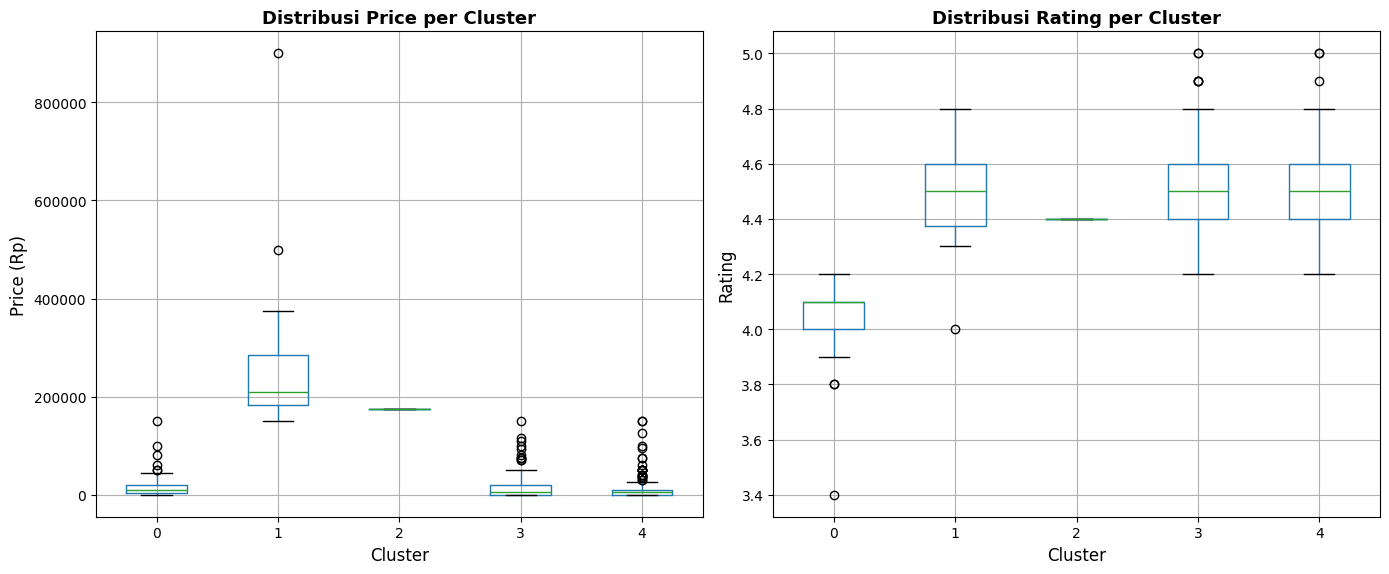

In [ ]:
# VIZ 2: Boxplot
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

df.boxplot(column='Price', by='Cluster', ax=axes[0])
axes[0].set_title('Distribusi Price per Cluster', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Cluster', fontsize=12)
axes[0].set_ylabel('Price (Rp)', fontsize=12)

df.boxplot(column='Rating', by='Cluster', ax=axes[1])
axes[1].set_title('Distribusi Rating per Cluster', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Cluster', fontsize=12)
axes[1].set_ylabel('Rating', fontsize=12)

plt.suptitle('')
plt.tight_layout()
plt.show()

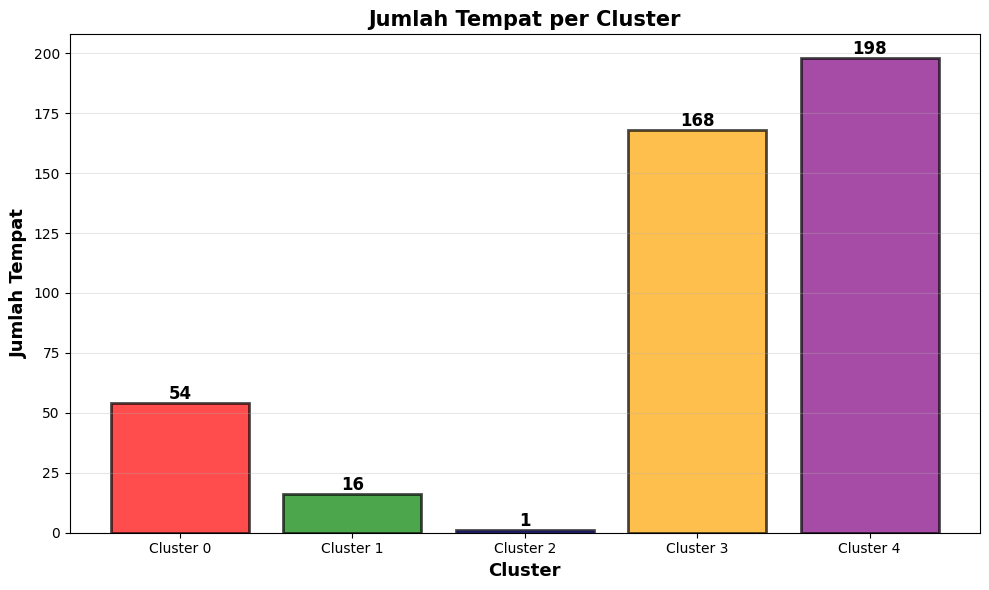

In [ ]:
# VIZ 3: Bar Chart
cluster_counts = df['Cluster'].value_counts().sort_index()

plt.figure(figsize=(10, 6))
bars = plt.bar(cluster_counts.index, cluster_counts.values,
               color=[colors[i] for i in cluster_counts.index],
               alpha=0.7, edgecolor='black', linewidth=2)
plt.xlabel('Cluster', fontsize=13, fontweight='bold')
plt.ylabel('Jumlah Tempat', fontsize=13, fontweight='bold')
plt.title('Jumlah Tempat per Cluster', fontsize=15, fontweight='bold')
plt.xticks(cluster_counts.index, [f'Cluster {i}' for i in cluster_counts.index])
plt.grid(True, alpha=0.3, axis='y')

for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height, f'{int(height)}',
             ha='center', va='bottom', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

#Sistem Rekomendasi

TF-IDF & Content Based Filtering

In [ ]:
# ========== SISTEM REKOMENDASI ==========
print("\n" + "="*80)
print("SETUP SISTEM REKOMENDASI")
print("="*80)

df['combined_text'] = (
    df['Place_Name'].astype(str) + " " +
    df['City'].astype(str) + " " +
    df['Category'].astype(str)
)

vectorizer = TfidfVectorizer(stop_words='english')
tfidf_matrix = vectorizer.fit_transform(df['combined_text'])


SETUP SISTEM REKOMENDASI


Hitung Jarak

In [ ]:
def calculate_distance(lat1, lon1, lat2, lon2):
    return geodesic((lat1, lon1), (lat2, lon2)).km

def get_coordinates(city_name, max_retries=3):
    """Ambil koordinat menggunakan Geopy"""

    # Cek dataset dulu
    city_lower = city_name.lower().strip()
    city_matches = df[df['City'].str.lower().str.contains(city_lower, na=False)]
    if not city_matches.empty:
        return (city_matches['Lat'].mean(), city_matches['Long'].mean())

    # Gunakan Geopy
    print(f"🔍 Mencari '{city_name}'...")

    for attempt in range(max_retries):
        try:
            location = geolocator.geocode(f"{city_name}, Indonesia", timeout=10)

            if location:
                print(f"✅ {location.address}")
                return (location.latitude, location.longitude)
            else:
                location = geolocator.geocode(city_name, timeout=10)
                if location:
                    print(f"✅ {location.address}")
                    return (location.latitude, location.longitude)

            return None

        except GeocoderTimedOut:
            if attempt < max_retries - 1:
                time.sleep(1)
            else:
                return None
        except:
            return None

    return None

Hybrid Recommendation

In [ ]:
def hybrid_recommendation(query, max_distance_km=100, max_price=None, min_rating=None, top_n=5):
    """Sistem Rekomendasi Hybrid"""

    coords = get_coordinates(query)

    if coords is None:
        print(f"❌ Lokasi '{query}' tidak ditemukan")
        return None

    center_lat, center_lon = coords
    print(f"📍 Lat: {center_lat:.6f}, Long: {center_lon:.6f}\n")

    # Hitung jarak
    df['distance_km'] = df.apply(
        lambda row: calculate_distance(center_lat, center_lon, row['Lat'], row['Long']),
        axis=1
    )

    # Hitung similarity
    query_vec = vectorizer.transform([query])
    df['similarity'] = cosine_similarity(query_vec, tfidf_matrix).flatten()

    # Filter
    filtered = df.copy()

    if max_distance_km:
        filtered = filtered[filtered['distance_km'] <= max_distance_km]

    if max_price:
        filtered = filtered[filtered['Price'] <= max_price]

    if min_rating:
        filtered = filtered[filtered['Rating'] >= min_rating]

    if filtered.empty:
        print("❌ Tidak ada tempat yang memenuhi kriteria")
        return None

    # Normalisasi score
    max_dist = filtered['distance_km'].max()
    filtered['distance_score'] = 1 - (filtered['distance_km'] / max_dist) if max_dist > 0 else 1

    filtered['similarity_score'] = filtered['similarity']
    filtered['rating_score'] = filtered['Rating'] / 5.0

    max_price_val = filtered['Price'].max()
    filtered['price_score'] = 1 - (filtered['Price'] / max_price_val) if max_price_val > 0 else 1

    # Hybrid score
    filtered['hybrid_score'] = (
        filtered['distance_score'] * 0.3 +
        filtered['similarity_score'] * 0.3 +
        filtered['rating_score'] * 0.2 +
        filtered['price_score'] * 0.2
    )

    result = filtered.sort_values('hybrid_score', ascending=False).head(top_n)

    return result[[
        'Place_Name', 'City', 'Category', 'Price', 'Rating',
        'distance_km', 'similarity', 'hybrid_score', 'Cluster'
    ]]

print("✅ Sistem rekomendasi siap!\n")

✅ Sistem rekomendasi siap!



Tampilkan Rekomendasi

In [ ]:
# ========== MENU ==========
while True:
    print("\n" + "="*80)
    print("MENU:")
    print("1. Karakteristik Cluster")
    print("2. Rekomendasi Tempat Wisata")
    print("3. Keluar")
    print("="*80)

    pilihan = input("\nPilih (1/2/3): ").strip()

    if pilihan == "1":
        print("\n" + "="*80)
        print("KARAKTERISTIK CLUSTER")
        print("="*80)

        for cluster_id in range(best_k):
            cluster_data = df[df['Cluster'] == cluster_id]

            print(f"\n{'='*80}")
            print(f"CLUSTER {cluster_id} ({len(cluster_data)} tempat)")
            print(f"{'='*80}")
            print(f"Rata-rata Price: Rp {cluster_data['Price'].mean():,.0f}")
            print(f"Rata-rata Rating: {cluster_data['Rating'].mean():.2f}")
            print(f"Price Range: Rp {cluster_data['Price'].min():,} - Rp {cluster_data['Price'].max():,}")
            print(f"Rating Range: {cluster_data['Rating'].min():.1f} - {cluster_data['Rating'].max():.1f}")

            if not cluster_data.empty:
                print(f"\nKategori populer: {cluster_data['Category'].mode().values[0]}")
                print(f"Top 3 kota:")
                top_cities = cluster_data['City'].value_counts().head(3)
                for city, count in top_cities.items():
                    print(f"  - {city}: {count} tempat")

            print("\nContoh tempat:")
            examples = cluster_data[['Place_Name', 'City', 'Price', 'Rating']].head(3)
            for idx, row in examples.iterrows():
                print(f"  - {row['Place_Name']} ({row['City']}) - Rp {row['Price']:,}, ⭐{row['Rating']}")

    elif pilihan == "2":
        print("\n" + "="*80)
        print("REKOMENDASI HYBRID")
        print("="*80)

        query = input("\nNama kota: ").strip()

        if not query:
            print("❌ Input tidak boleh kosong!")
            continue

        try:
            max_dist = input("Radius (km, default=100): ").strip()
            max_dist = int(max_dist) if max_dist else 100
        except:
            max_dist = 100

        try:
            max_price_input = input("Budget max (Rp, enter=unlimited): ").strip()
            max_price = int(max_price_input) if max_price_input else None
        except:
            max_price = None

        try:
            min_rating_input = input("Rating min (0-5, enter=0): ").strip()
            min_rating = float(min_rating_input) if min_rating_input else None
        except:
            min_rating = None

        results = hybrid_recommendation(query, max_dist, max_price, min_rating, 5)

        if results is not None:
            print(f"\n{'='*80}")
            print(f"TOP 5 REKOMENDASI dari '{query}'")
            print(f"{'='*80}")

            for idx, row in results.iterrows():
                print(f"\n{row['Place_Name']} (Cluster {row['Cluster']})")
                print(f"  📍 {row['City']} | 🏷️ {row['Category']}")
                print(f"  💰 Rp {row['Price']:,} | ⭐ {row['Rating']}")
                print(f"  📏 {row['distance_km']:.2f} km | 🎯 Score: {row['hybrid_score']:.4f}")

    elif pilihan == "3":
        print("\n" + "="*80)
        print("Terima kasih!")
        print("="*80)
        break

    else:
        print("\n❌ Pilihan tidak valid!")


MENU:
1. Karakteristik Cluster
2. Rekomendasi Tempat Wisata
3. Keluar

Pilih (1/2/3): 1

KARAKTERISTIK CLUSTER

CLUSTER 0 (54 tempat)
Rata-rata Price: Rp 17,981
Rata-rata Rating: 4.05
Price Range: Rp 0 - Rp 150,000
Rating Range: 3.4 - 4.2

Kategori populer: Taman Hiburan
Top 3 kota:
  - Bandung: 22 tempat
  - Semarang: 15 tempat
  - Yogyakarta: 10 tempat

Contoh tempat:
  - Pulau Pari (Jakarta) - Rp 150,000, ⭐4.0
  - Pasar Tanah Abang (Jakarta) - Rp 0, ⭐4.0
  - Pulau Semak Daun (Jakarta) - Rp 40,000, ⭐4.0

CLUSTER 1 (16 tempat)
Rata-rata Price: Rp 284,375
Rata-rata Rating: 4.47
Price Range: Rp 150,000 - Rp 900,000
Rating Range: 4.0 - 4.8

Kategori populer: Taman Hiburan
Top 3 kota:
  - Jakarta: 8 tempat
  - Bandung: 4 tempat
  - Yogyakarta: 3 tempat

Contoh tempat:
  - Dunia Fantasi (Jakarta) - Rp 270,000, ⭐4.6
  - Ocean Ecopark (Jakarta) - Rp 180,000, ⭐4.0
  - Pulau Pelangi (Jakarta) - Rp 900,000, ⭐4.8

CLUSTER 2 (1 tempat)
Rata-rata Price: Rp 175,000
Rata-rata Rating: 4.40
Price Ran